# Tasks

- First, explore fitting this data with the tecniques we have seen.
- Start from linear regression and polynomial regression
- For the case of  polynomial regression, just fit many of them for now.
- Let's bet based on intuition! Which fit is the best?
- In what cases are you underfitting the data?
- In what cases are you overfitting the data?
- Now split the data into training and validation sets
- Implement a cross-validation procedure
- Pick the best!
- Does it agree with our bets?

## OPTIONAL
- Repeat with Basis Function Regression and Kernel Regression
- Explore what happens when you change the number of datapoints and plot the resulting learning curves.

# import 

In [ ]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import learning_curve
from sklearn.model_selection import KFold, cross_val_score
# from astroML.linear_model import PolinomialRegression
#non posso poiché non ho PyMC3 e se provo ad installarlo dà problemi
#uso PolynomialFeatures di sklearn


# code

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_9017/4129113698.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


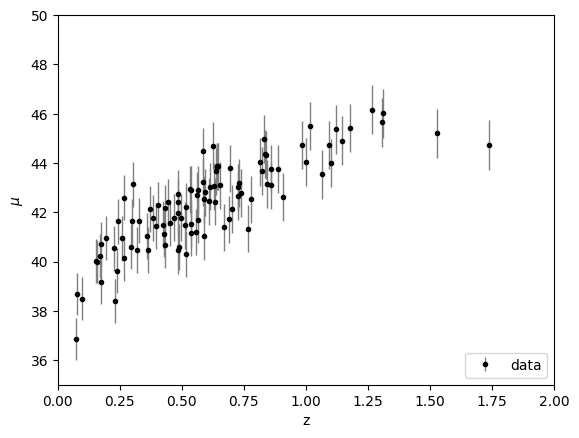

In [ ]:

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

39.48384602295729 [4.76438865]


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_9017/2588478566.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


(35.0, 50.0)

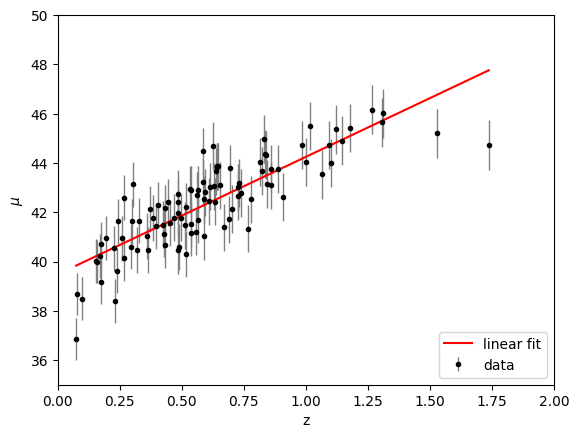

In [ ]:
# trying with linear regression
weights = 1/dmu**2
lin_reg = LinearRegression()

lin_reg.fit(z_sample.reshape(-1, 1), mu_sample, sample_weight=weights)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)
z_line = np.linspace(z_sample.min(), z_sample.max(), 200)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(z_line, lin_reg.predict(z_line.reshape(-1, 1)), '-', color='red', label='linear fit')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0, 2)
plt.ylim(35, 50)

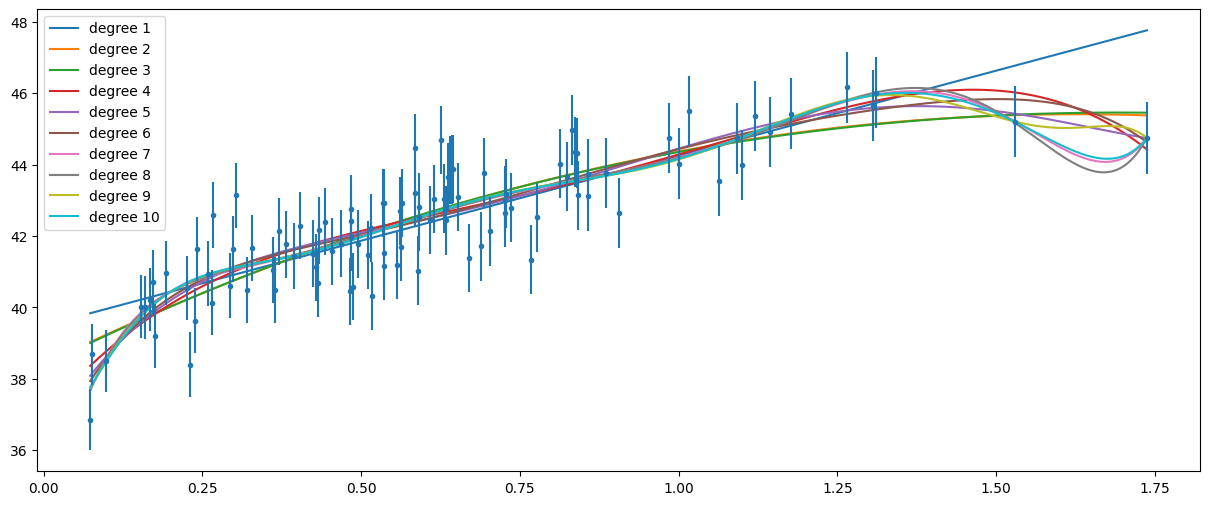

In [ ]:
z_line = np.linspace(z_sample.min(), z_sample.max(), 600)
plt.figure(figsize= (15, 6))
for i in range (10):
    poli = PolynomialFeatures(degree= i+1)
    z_poli = poli.fit_transform(z_sample.reshape(-1, 1))
    lin_reg = LinearRegression()
    lin_reg.fit(z_poli, mu_sample, weights)
    theta0 = lin_reg.intercept_
    z_line_poly = poli.transform(z_line.reshape(-1, 1))
    plt.plot(z_line, lin_reg.predict(z_line_poly), '-', label=f'degree {i+1}')
plt.errorbar(z_sample, mu_sample, dmu, fmt = '.')
plt.legend()

(30.0, 60.0)

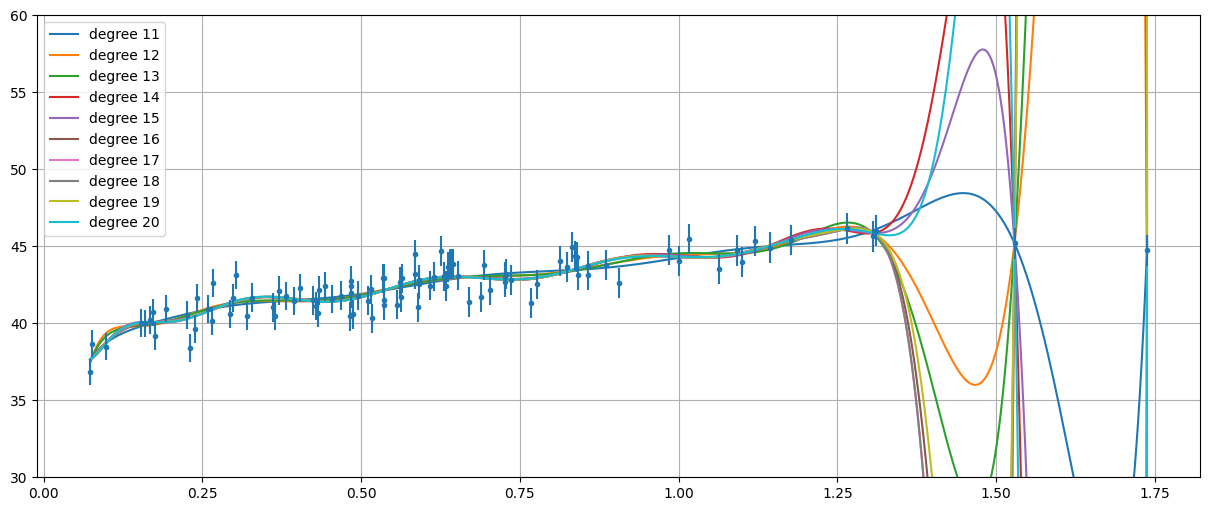

In [ ]:
z_line = np.linspace(z_sample.min(), z_sample.max(), 600)
plt.figure(figsize= (15, 6))
for i in range (10):
    poli = PolynomialFeatures(degree= i+11)
    z_poli = poli.fit_transform(z_sample.reshape(-1, 1))
    lin_reg = LinearRegression()
    lin_reg.fit(z_poli, mu_sample, weights)
    theta0 = lin_reg.intercept_
    z_line_poly = poli.transform(z_line.reshape(-1, 1))
    plt.plot(z_line, lin_reg.predict(z_line_poly), '-', label=f'degree {i+11}')
plt.errorbar(z_sample, mu_sample, dmu, fmt = '.')
plt.legend()
plt.grid()
plt.ylim(30,60)

i think it is a poli of degree ~ 5

In [ ]:
## now split the data in 60 % training, 20% test, 20% validation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from astroML.linear_model import PolynomialRegression


z_test, z_temp, mu_test, mu_temp, dmu_test, dmu_temp = train_test_split(z_sample, mu_sample, dmu, train_size=0.20, )

z_train, z_val, mu_train, mu_val, dmu_train, dmu_val = train_test_split(z_temp, mu_temp, dmu_temp, train_size=0.75, )

# Create k=4 subsets for cross-validation from training data


/home/matti/uni/lab/myenv/lib/python3.12/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


In [ ]:

kfold = KFold(n_splits = 4, shuffle=True)
model = PolynomialRegression(4)
scores = cross_val_score(model, z_temp.reshape(-1, 1), mu_temp, cv = kfold, scoring = 'neg_mean_squared_error')

print(scores)

#i have to do a manual loop to try different models

[-0.91013133 -0.5181075  -1.10567821 -0.71142659]


In [ ]:
z_temp = z_temp.reshape(-1, 1)
z_test = z_test.reshape(-1, 1)

In [ ]:

cv_scores = []
test_scores = []
models = [PolynomialRegression(3), PolynomialRegression(5), PolynomialRegression(10), PolynomialRegression(17)]
for model in models:
    for (train_index, test_index) in zip(kfold.split(z_temp)):
        z_train, z_cv_test = z_temp[train_index], z_temp[test_index]
        mu_train, mu_cv_test = mu_temp[train_index], mu_temp[test_index]
        model.fit(z_train, mu_train)
        mu_cv_predicted = model.predict(z_cv_test)
        mu_test_predicted = model.predict(z_test)
        cv_score = mean_squared_error(mu_cv_test, mu_cv_predicted)
        test_score = mean_squared_error(mu_test, mu_test_predicted)
        cv_scores.append(cv_score)
        test_scores.append(test_score)
        # print(f"Model: {type(model).__name__}({model.degree}), cv MSE: {cv_score:.4f}, test MSE: {test_score:.4f}")
    avg_cv = np.mean(cv_scores)
    avg_test = np.mean(test_scores)
    
    print(f"Model: {type(model).__name__}({model.degree}) | Avg cv MSE: {avg_cv:.4f} | Avg test MSE: {avg_test:.4f}")


ValueError: not enough values to unpack (expected 2, got 1)

the less is better

accuracy of kfold <function cross_val_score at 0x7f06565e8680>
